In [ ]:
import sys;sys.path.append('../..')
from abslithist import *

In [ ]:
df_fic = pd.read_csv(os.path.expanduser('~/lltk_data/corpora/hathi_englit/fiction_yearly_summary.csv'))
df_poe = pd.read_csv(os.path.expanduser('~/lltk_data/corpora/hathi_englit/poetry_yearly_summary.csv'))

In [ ]:
norm_d = get_norm_dict()

df = pd.concat([df_fic.assign(genre='Fiction'), df_poe.assign(genre='Verse')])

In [26]:
gby = ['genre','year']
o = []
for g,gdf in tqdm(df.groupby(gby)):
    out = []
    for word,count in zip(gdf.word, gdf.termfreq):
        if word in norm_d:
            for n in range(count):
                out.append(norm_d[word])
    score = np.mean(out)
    od = dict(zip(gby, g))
    od['score'] = score
    o.append(od)
odf = pd.DataFrame(o)
odf

 42%|████▏     | 183/434 [01:30<02:03,  2.03it/s]


KeyboardInterrupt: 

In [33]:
gby = ["genre", "year"]

# Build a unique mapper from norm_d (handles duplicate word keys)
norm_s = pd.Series(norm_d)
norm_map = norm_s.groupby(level=0).mean()  # use .first() or .last() if preferred

tmp = (
    df.assign(norm=df["word"].map(norm_map))
      .dropna(subset=["norm"])  # keep only words that have a score
      .assign(weighted=lambda d: d["norm"] * d["termfreq"])
)

odf = (
    tmp.groupby(gby, as_index=False)
       .agg(
           weighted_sum=("weighted", "sum"),
           weight_sum=("termfreq", "sum"),
       )
)

odf["score"] = odf["weighted_sum"] / odf["weight_sum"]
odf = odf[gby + ["score"]]
odf.to_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.HathiEngLitSummary.pkl'))

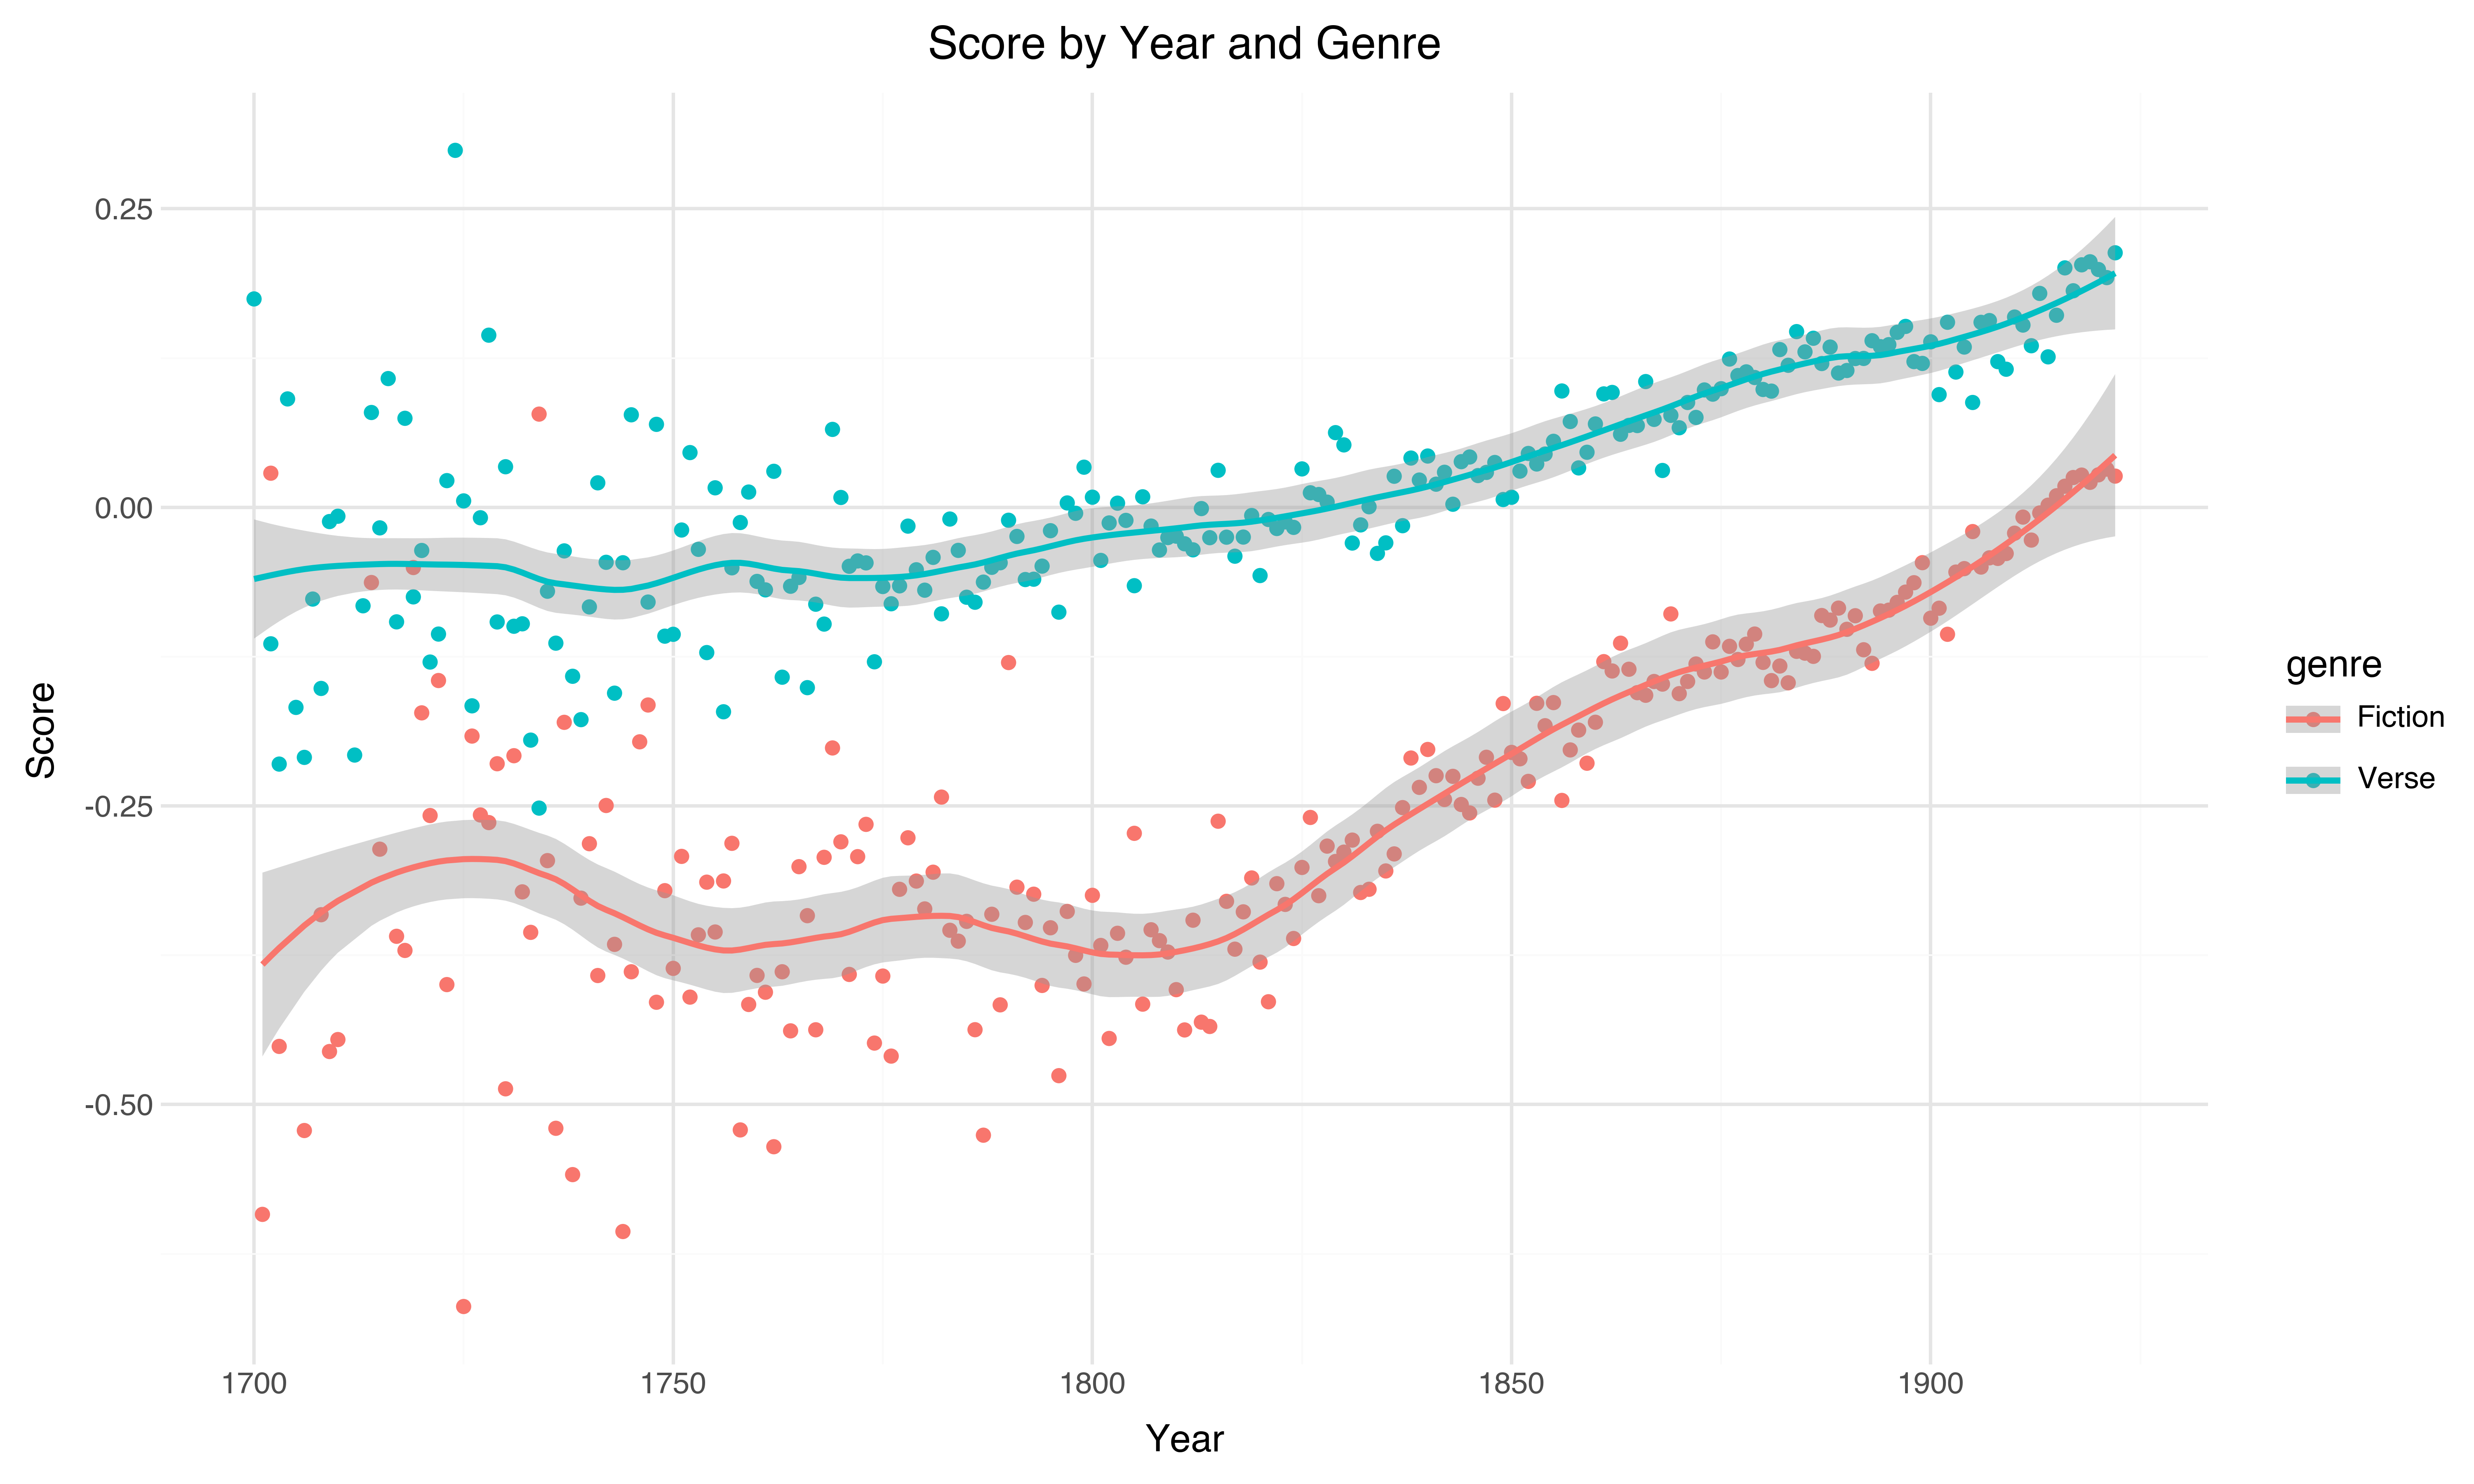

In [34]:
p9.options.dpi=300
p9.options.figure_size=(10,6)

fig = (
    p9.ggplot(odf, p9.aes(x='year', y='score', color='genre'))
    + p9.geom_point()
    + p9.theme_minimal()
    + p9.labs(x='Year', y='Score', title='Score by Year and Genre')
    + p9.geom_smooth(method='loess', span=0.3)
)
fig

